In [20]:
!pip install shap

In [21]:
import numpy as np
import pickle

x_train = np.load("../../data/x_train_resampled.npy")
x_test = np.load("../../data/x_test.npy")

with open("../../models/fraud_model.pkl", "rb") as f:
    rf_model = pickle.load(f)

print("Model Loaded Successfully")

Model Loaded Successfully


In [22]:
import shap
explainer = shap.TreeExplainer(rf_model)

print("Explainer created successfully")

Explainer created successfully


In [23]:
import numpy as np

sample_idx = np.random.choice(
    len(x_test),
    500,
    replace=False
)

x_test_sample = x_test[sample_idx]

shap_values = explainer.shap_values(x_test_sample)
print("SHAP values generated successfully")

SHAP values generated successfully


In [24]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(500, 30, 2)


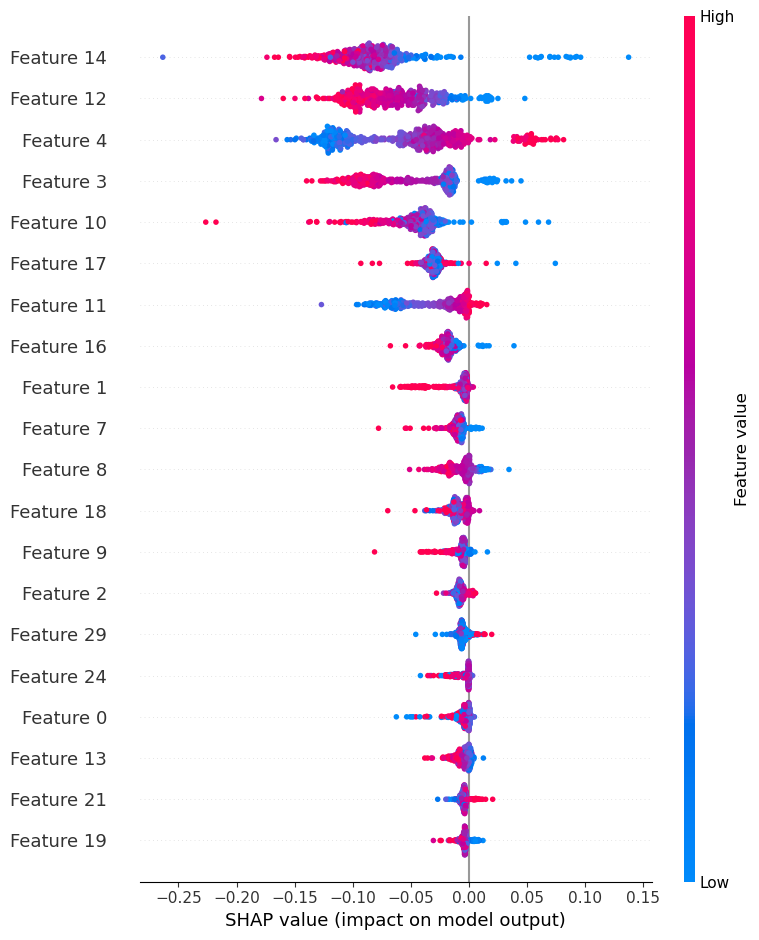

In [25]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values[:, :, 1],
    x_test_sample,
    show=False
)

plt.tight_layout()
plt.show()  

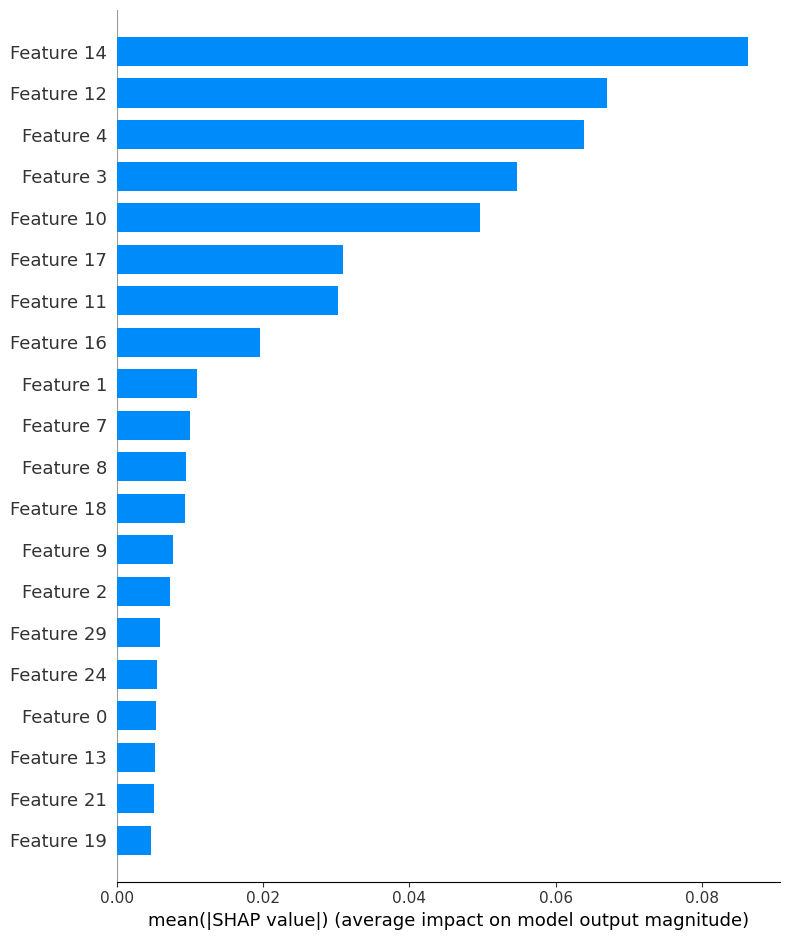

In [26]:
shap.summary_plot(
    shap_values[:, :, 1],
    x_test_sample,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

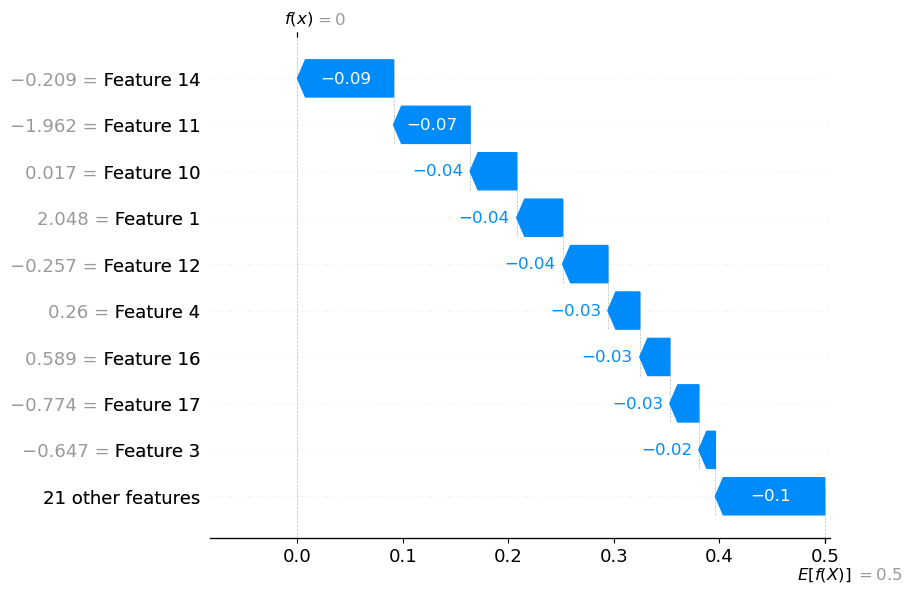

In [27]:
fraud_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_index, :, 1],
        base_values=explainer.expected_value[1],
        data=x_test_sample[fraud_index]
    )
)